# Stacked model trajectories
One plot per ROI with the empirical trajectory on top and each model's *N* stochastic simulations (with mean +/- 1 std band) stacked below, vertically translated to avoid collisions.
Inspired by `pipeline_stacked_signals.ipynb` (stacking style) and `nsde_timeseries.pdf` (per-model sim style).

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

project_root = Path.cwd()
if project_root.name == 'examples':
    os.chdir(project_root.parent)
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

plt.rcParams['figure.dpi'] = 140
%matplotlib inline

In [ ]:
%matplotlib inline

In [8]:
DATASET_TYPE   = 'ts_young'
DATA_PATH      = 'data/ts_young/ts_young_TR0.72.mat'
LSD_DATA_DIR   = 'data/lsd'
CHECKPOINT_DIR = 'checkpoints'
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'

N_TIMEPOINTS   = 200
N_SIMULATIONS  = 3            # per-model stochastic runs from same IC
ROI_INDICES    = [0]   # one stacked figure per ROI
SUBJECT_INDEX  = 0             # which subject's IC to use as empirical reference

OUT_DIR_PDF = Path(f'paper/images/{DATASET_TYPE}')
OUT_DIR_PNG = Path(f'paper/images_png/{DATASET_TYPE}')
OUT_DIR_SVG = Path(f'paper/images_svg/{DATASET_TYPE}')
for d in (OUT_DIR_PDF, OUT_DIR_PNG, OUT_DIR_SVG):
    d.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')

Device: cpu


In [9]:
from src.dataset import load_dataset
from src.training import HopfConfig

cfg = HopfConfig()
cfg.dataset_type = DATASET_TYPE
cfg.data_path    = DATA_PATH
cfg.lsd_data_dir = LSD_DATA_DIR
cfg.use_wandb    = False

dataset = load_dataset(cfg, DEVICE)
print(f'n_rois={dataset.n_rois}  n_subjects={dataset.timeseries.shape[0]}  n_timepoints={dataset.n_timepoints}  dt={dataset.dt}')

Loaded dataset:
  - subjects=94  ROIs=100  T=1200
  - FC shape=torch.Size([100, 100])  dtype=torch.complex64  dt=0.72s
  - control_dims=0
n_rois=100  n_subjects=94  n_timepoints=1200  dt=0.72


In [10]:
from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ('hybrid_neural', 'Hybrid+Neural'),
    ('hybrid_hopf',   'Hybrid Hopf'),
    ('gnn_hopf',      'GNN Hopf'),
    ('nsde',          'Neural SDE'),
    ('hopf',          'Hopf'),
]

def _short_label(stem: str) -> str:
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (' (Grid)' if 'grid' in lower else '')
    return stem

ckpt_dir = Path(CHECKPOINT_DIR)
checkpoint_paths = sorted(ckpt_dir.glob(f'*{DATASET_TYPE}*.pt'))

models = {}
for ckpt_path in checkpoint_paths:
    try:
        model, mtype, _ = load_model_from_checkpoint(str(ckpt_path), device=DEVICE)
        if model.n_rois != dataset.n_rois:
            continue
        models[_short_label(ckpt_path.stem)] = model
    except Exception as exc:
        print(f'  Failed to load {ckpt_path.name}: {exc}')

print(f'Loaded {len(models)} model(s): {list(models.keys())}')

Loaded 6 model(s): ['GNN Hopf', 'Hopf', 'Hopf (Grid)', 'Hybrid Hopf', 'Hybrid+Neural', 'Neural SDE']


In [11]:
# Empirical reference: one subject, full timeseries.
real_ts = dataset.timeseries[SUBJECT_INDEX]                  # (n_rois, T)  may be complex
if torch.is_complex(real_ts):
    real_plot = real_ts.real[:, :N_TIMEPOINTS]
else:
    real_plot = real_ts[:, :N_TIMEPOINTS]
real_plot = real_plot.detach().cpu().numpy()                  # (n_rois, T)

# IC for stochastic forwards: take it from the same subject's t=0
ic = real_ts[:, 0]                                            # (n_rois,)
ic_repeated = ic.unsqueeze(0).expand(N_SIMULATIONS, -1)       # (n_sim, n_rois)

torch.manual_seed(0)
sim_per_model = {}
for name, model in models.items():
    with torch.no_grad():
        sim_ts = model.forward(initial_state=ic_repeated, n_steps=N_TIMEPOINTS)  # (n_sim, n_rois, T)
    sim_real = sim_ts.real if torch.is_complex(sim_ts) else sim_ts
    sim_per_model[name] = sim_real.detach().cpu().numpy()
    print(f'  {name}: simulated shape={sim_per_model[name].shape}')

  GNN Hopf: simulated shape=(3, 100, 200)
  Hopf: simulated shape=(3, 100, 200)
  Hopf (Grid): simulated shape=(3, 100, 200)
  Hybrid Hopf: simulated shape=(3, 100, 200)
  Hybrid+Neural: simulated shape=(3, 100, 200)
  Neural SDE: simulated shape=(3, 100, 200)


In [75]:
import numpy as np
import matplotlib.pyplot as plt

def stacked_trajectories(
    real_signal,                # (T,) empirical reference for one ROI
    sims_per_model,             # dict name -> (n_sim, T) for the same ROI
    models_to_plot=["Hopf", "Neural SDE", "Hybrid Hopf"],         # optional list of model names to include (default: all in sims_per_model)
    *,
    dt=1.0,
    figsize=(2.5, .7),          # height per stacked row
    save_stem=None,             # filename stem (no extension) under OUT_DIR_*
):
    # Filter the dictionary if specific models are requested
    if models_to_plot is not None:
        sims_per_model = {name: sims_per_model[name] for name in models_to_plot if name in sims_per_model}

    n_rows = 1 + len(sims_per_model)
    T = real_signal.shape[0]
    time = np.arange(T) * dt

    # 1. ADD gridspec_kw={'hspace': 0.0} TO REMOVE MARGINS BETWEEN PLOTS
    fig, axes = plt.subplots(
        n_rows, 1, 
        figsize=(figsize[0], figsize[1] * n_rows), 
        sharex=True,
        gridspec_kw={'hspace': 0.3} 
    )
    fig.patch.set_alpha(0.0)
    
    if n_rows == 1:
        axes = [axes]

    # --- empirical (blue) ---
    real_color = '#1f77b4'
    axes[0].plot(time, real_signal, color=real_color, lw=1.4, label='Empirical')
    
    # 2. ADD bbox_to_anchor TO THE EMPIRICAL LEGEND TO RAISE IT
    # The '1.3' pushes it higher. Adjust this number if you need it higher/lower.
    axes[0].legend(loc='upper right', frameon=False, fontsize=9, bbox_to_anchor=(1.0, 1.3))

    # --- per-model rows ---
    cmap = plt.cm.Reds
    red_colors = cmap(np.linspace(0.4, 0.9, len(sims_per_model)))

    for i, (name, sims) in enumerate(sims_per_model.items(), start=1):
        ax = axes[i]
        color = red_colors[i - 1]
        
        mu = sims.mean(axis=0)
        sd = sims.std(axis=0)

        # individual stochastic trajectories (faint)
        for k in range(sims.shape[0]):
            ax.plot(
                time, sims[k],
                color=color, lw=0.5, alpha=0.35,
            )
            
        # mean and +/-1 std band
        ax.fill_between(
            time, mu - sd, mu + sd,
            color=color, alpha=0.20, linewidth=0,
        )
        
        # Add label to the main line, then generate the subplot's legend
        ax.plot(
            time, mu, color=color, lw=1.4, alpha=0.95, label=name
        )
        
        # 3. INCREASE THE Y-VALUE IN bbox_to_anchor TO RAISE THESE LEGENDS
        ax.legend(loc='upper right', frameon=False, fontsize=9, bbox_to_anchor=(1.0, 1.5))

    # --- cosmetics for all subplots ---
    for i, ax in enumerate(axes):
        # 1. Remove left, right, and top spines completely
        for side in ('top', 'right', 'left'):
            ax.spines[side].set_visible(False)
            
        # 2. Remove all y-ticks and labels
        ax.set_yticks([]) 

        # 3. Handle the bottom spine (x-axis)
        if i < len(axes) - 1:
            # Hide bottom spine and ticks for all upper plots
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(bottom=False, labelbottom=False)
        else:
            # On the bottom plot, remove tick marks but keep labels
            ax.tick_params(bottom=False, labelbottom=True)
            
        ax.set_xlim(time[0], time[-1])

    # --- Lower axis arrow and label ---
    axes[-1].set_xlabel('Time (s)')
    axes[-1].set_xticks([])
    # Draw an arrow head at the far right of the bottom axis
    axes[-1].plot(time[-1], 0, marker='>', color='black', markersize=6, 
                  transform=axes[-1].get_xaxis_transform(), clip_on=False)

    # 4. REMOVE OR REPLACE fig.tight_layout()
    # tight_layout() often overrides hspace=0. Use subplots_adjust instead if you need 
    # to pad the outer edges of the figure, though bbox_inches='tight' usually handles this.
    # fig.tight_layout() 
    fig.subplots_adjust(hspace=0.0)

    if save_stem is not None:
        # bbox_inches='tight' will ensure the newly raised legends aren't cut off in the saved file
        fig.savefig(OUT_DIR_PDF / f'{save_stem}.pdf', bbox_inches='tight')
        fig.savefig(OUT_DIR_PNG / f'{save_stem}.png', bbox_inches='tight', dpi=200)
        fig.savefig(OUT_DIR_SVG / f'{save_stem}.svg', bbox_inches='tight')
        
    return fig

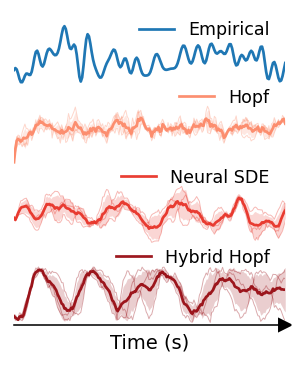

In [76]:
for roi in ROI_INDICES:
    sims_for_roi = {name: sims[:, roi, :] for name, sims in sim_per_model.items()}
    fig = stacked_trajectories(
        real_signal=real_plot[roi],
        sims_per_model=sims_for_roi,
        dt=dataset.dt,
        #title=f'ROI {roi} - empirical vs per-model simulations',
        save_stem=f'stacked_model_trajectories_roi{roi:03d}',
    )
    plt.show()
    plt.close(fig)